In [43]:
import pickle
import numpy as np
import os

# One measure of diversity: Sum of squared distances between all pairs

In [44]:
def cumulated_squared_distance_to_cloud(tab):
    '''
    returns sum of pair wise squared distances
    '''
    max_ = np.max(tab,axis=0)
    factors = np.array([1.0/400 if max_[j]>1.0 else 1.0 for j in range(tab.shape[1])]).reshape((1,    -1))
    factors = factors/np.sum(factors)
    idx = np.array([j for j in range(tab.shape[1]) if max_[j]<=1.0])
    diff = lambda j: np.sum(((tab[j+1:,idx]-tab[j,idx]))**2)
    diff_ = np.vectorize(diff)
    start = time.time()
    sum_ = np.sum(diff_(np.arange(len(tab))))
    print(time.time()-start)
    return sum_

In [45]:
def cumulated_squared_distance_to_cloud(tab):
    '''
    returns sum of pair wise squared distances
    '''
    max_ = np.max(tab,axis=0)
    idx = np.array([j for j in range(tab.shape[1]) if max_[j]<=1.0])
    diff = lambda j: np.sum(((tab[j+1:,idx]-tab[j,idx]))**2)
    diff_ = np.vectorize(diff)
    start = time.time()
    sum_ = np.sum(diff_(np.arange(len(tab))))
    print(time.time()-start)
    return sum_

# Function to load most recent files

In [46]:
def load(name):
    k = 1
    while os.path.isfile(f"{name}_{k}.pkl"):
        k+=1
    k-=1
    with open(f'{name}_{k}.pkl','rb') as f:
        contentbis = pickle.load(f)
        print(f'{name}_{k}.pkl')
    
    return contentbis

# Compute diversity of IMGEP results for a couple of iterations

In [47]:
N = 10000
#folder = 'non_exclusive_axis_exploration3'
folder = 'non_exclusive_axis_exploration'
name = f'{folder}/rand_run_{N}'
content_rand = load(name)

non_exclusive_axis_exploration/rand_run_10000_1.pkl


In [60]:
max_ = np.max(content_rand['tabular_view'],axis=0)
idx = np.where(max_<=1.0)[0]
diff = lambda tab,j: np.sum(np.abs(tab[j+1:,idx]-tab[j,idx])**2,axis=1)
distances = [[] for j in range(N)]
diversities_rand = np.zeros((N//1000)+1)
s_list = [0]
for j in range(N):
    distances[j] = diff(content_rand['tabular_view'],j)
for j,n in enumerate(range(0,N+1,1000)):
    diversities_rand[j] = np.sum([np.sum(o[:n-i]) for i,o in  enumerate(distances[:n])])

diversities = np.zeros((1,3,1+N//1000))
for f,folder in enumerate(['non_exclusive_axis_exploration']):
    for i,k in enumerate([1,2,3]):
        for s in s_list:
            name = f'{folder}/imgep_run_{k}_{N}_s_{s}'
            content_imgep = load(name)
            distances = [[] for j in range(len(content_imgep['tabular_view']))]
            for j in range(len(content_imgep['tabular_view'])):
                distances[j] = diff(content_imgep['tabular_view'],j)
            for j,n in enumerate(range(0,N+1,1000)):
                diversities[f,i,j] = np.sum([np.sum(o[:n-i]) for i,o in  enumerate(distances[:n])])

non_exclusive_axis_exploration/imgep_run_1_10000_s_0_10.pkl
non_exclusive_axis_exploration/imgep_run_2_10000_s_0_10.pkl
non_exclusive_axis_exploration/imgep_run_3_10000_s_0_9.pkl


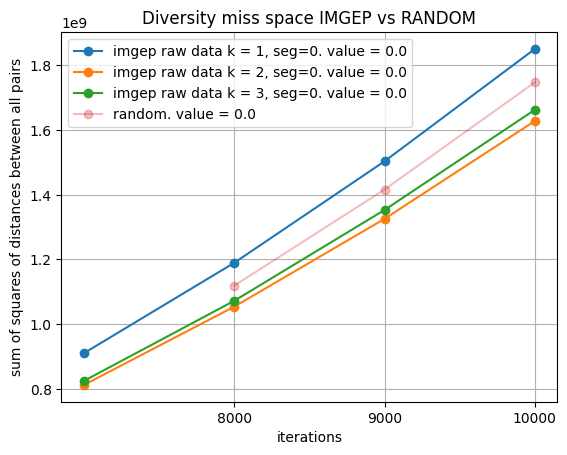

In [61]:
import matplotlib.pyplot as plt
plt.figure()
for f,folder in  enumerate(['imgep raw data']):
    for i,k in enumerate([1,2,3]):
        for s in s_list:
            plt.plot(np.arange(0,N+1,1000)[-4:],diversities[f,i][-4:],'-o',label=f'{folder} k = {k}, seg={s}. value = {round(diversities[f,i][-1]/1e13,2)}')
plt.plot(np.arange(0,N+1,1000)[-3:],diversities_rand[-3:],'-o',label=f'random. value = {round(diversities[f,i][-1]/1e13,2)}',alpha=.3)
plt.grid()
plt.title('Diversity miss space IMGEP vs RANDOM')
plt.ylabel('sum of squares of distances between all pairs')
plt.xlabel('iterations')
plt.xticks(range(8000,10001,1000))
plt.legend()
plt.show()

In [62]:
tab = content_rand['tabular_view']
max_ = np.max(tab,axis=0)
factors = np.ones(len(max_))
factors[np.where(max_<=1.0)[0]] = 200
idx = np.array([j for j in range(tab.shape[1]) if max_[j]<=1.0])
diff = lambda j: np.sum((factors*(tab[j+1:,:]-tab[j,:]))**2,axis=1)
distances = [[] for j in range(len(tab))]
diversities_rand = np.zeros((len(tab)//1000)+1)


for j in range(len(tab)):
    distances[j] = diff(j)
for j,n in enumerate(range(0,len(tab)+1,1000)):
    diversities_rand[j] = np.sum([np.sum(o[:n-i]) for i,o in  enumerate(distances[:n])])

diversities = np.zeros((1,3,1+len(tab)//1000))
for f,folder in enumerate(['non_exclusive_axis_exploration']):
    for i,k in enumerate([1,2,3]):
        for s in s_list:
            name = f'{folder}/imgep_run_{k}_{N}_s_{s}'
            content_imgep = load(name)
            tab = content_imgep['tabular_view']
            max_ = np.max(tab,axis=0)
            idx = np.array([j for j in range(tab.shape[1]) if max_[j]<=1.0])
            diff = lambda j: np.sum((factors*(tab[j+1:,:]-tab[j,:]))**2,axis=1)
            distances = [[] for j in range(len(tab))]
            for j in range(len(tab)):
                distances[j] = diff(j)
            for j,n in enumerate(range(0,len(tab)+1,1000)):
                diversities[f,i,j] = np.sum([np.sum(o[:n-i]) for i,o in  enumerate(distances[:n])])

non_exclusive_axis_exploration/imgep_run_1_10000_s_0_10.pkl
non_exclusive_axis_exploration/imgep_run_2_10000_s_0_10.pkl
non_exclusive_axis_exploration/imgep_run_3_10000_s_0_9.pkl


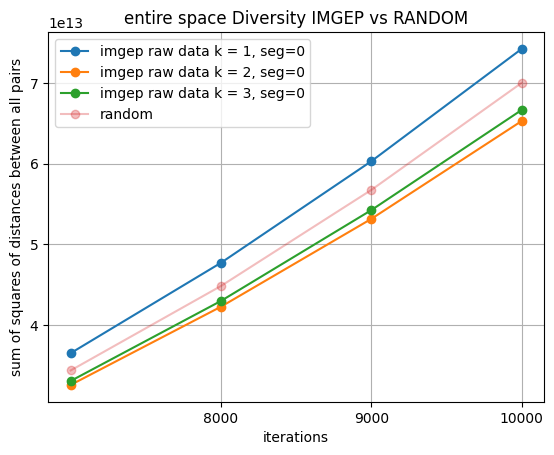

In [63]:
import matplotlib.pyplot as plt
plt.figure()
for f,folder in  enumerate(['imgep raw data']):
    for i,k in enumerate([1,2,3]):
        for s in s_list:
            plt.plot(np.arange(0,N+1,1000)[-4:],diversities[f,i][-4:],'-o',label=f'{folder} k = {k}, seg={s}')
plt.plot(np.arange(0,N+1,1000)[-4:],diversities_rand[-4:],'-o',label=f'random',alpha=.3)
plt.grid()
plt.title('entire space Diversity IMGEP vs RANDOM')
plt.ylabel('sum of squares of distances between all pairs')
plt.xlabel('iterations')
plt.xticks(range(8000,10001,1000))
plt.legend()
plt.show()

# Time space diversity

non_exclusive_axis_exploration/imgep_run_1_10000_s_0_10.pkl
non_exclusive_axis_exploration/imgep_run_2_10000_s_0_10.pkl
non_exclusive_axis_exploration/imgep_run_3_10000_s_0_9.pkl
dict_keys(['memory_perf', 'memory_program', 'tabular_view', 'names'])
dict_keys(['memory_perf', 'memory_program', 'tabular_view', 'names'])
dict_keys(['memory_perf', 'memory_program', 'tabular_view', 'names'])
dict_keys(['memory_perf', 'memory_program', 'tabular_view', 'names'])


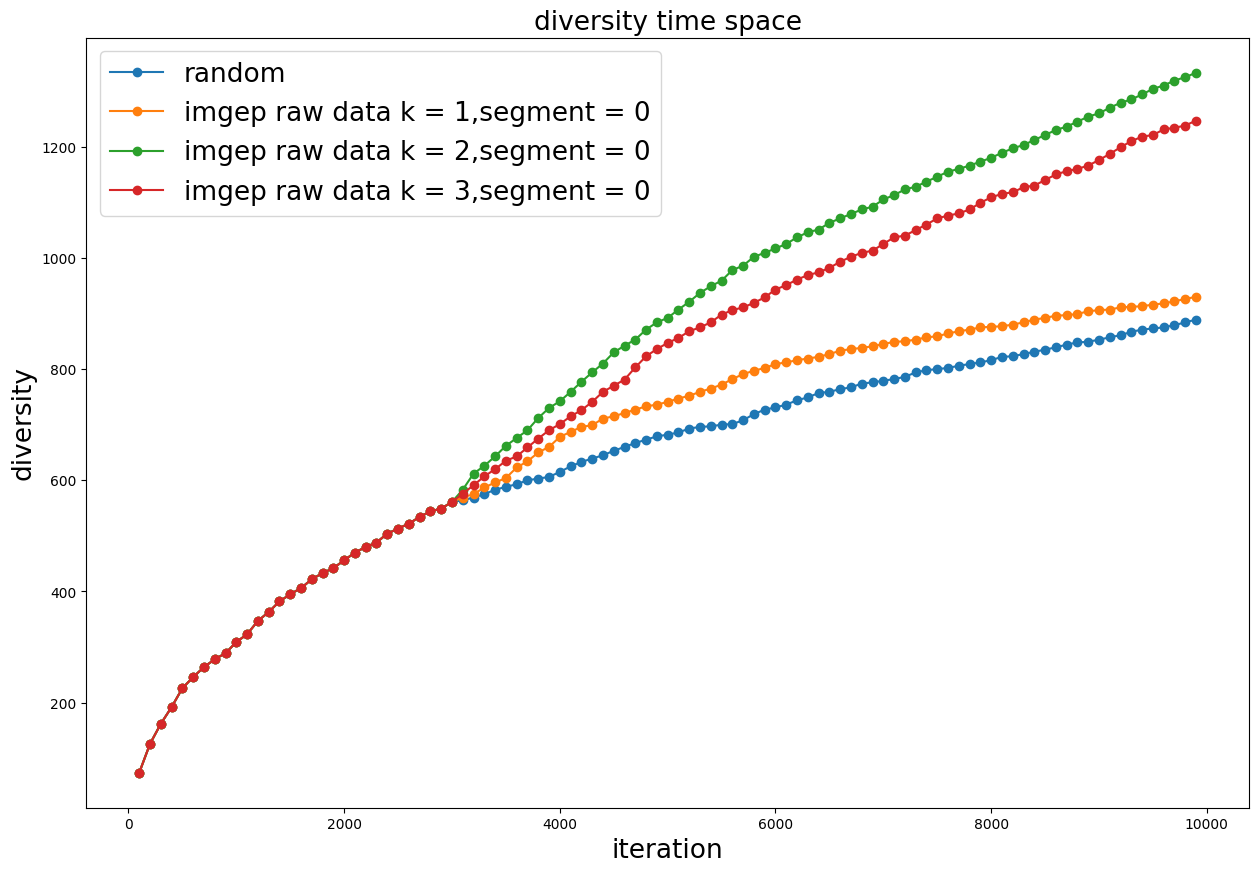

In [64]:
from visualisation.visu_time import diversity_time_iteration

diversity_time_iteration([(content_rand,'random')]+
                         [(load(f'{folder}/imgep_run_{k}_{N}_s_{s}'),f"{['imgep raw data'][f]} k = {k},segment = {s}") for k in [1,2,3] for s in s_list for f,folder in enumerate(['non_exclusive_axis_exploration'])], name=f'iteration_time_',title=f'diversity time space',folder='..')

In [41]:
from visualisation.visu import hist_diversity_misses

non_exclusive_axis_exploration/imgep_run_2_10000_s_1_1.pkl
non_exclusive_axis_exploration/imgep_run_3_10000_s_1_1.pkl
non_exclusive_axis_exploration/imgep_run_1_10000_s_1_0.pkl


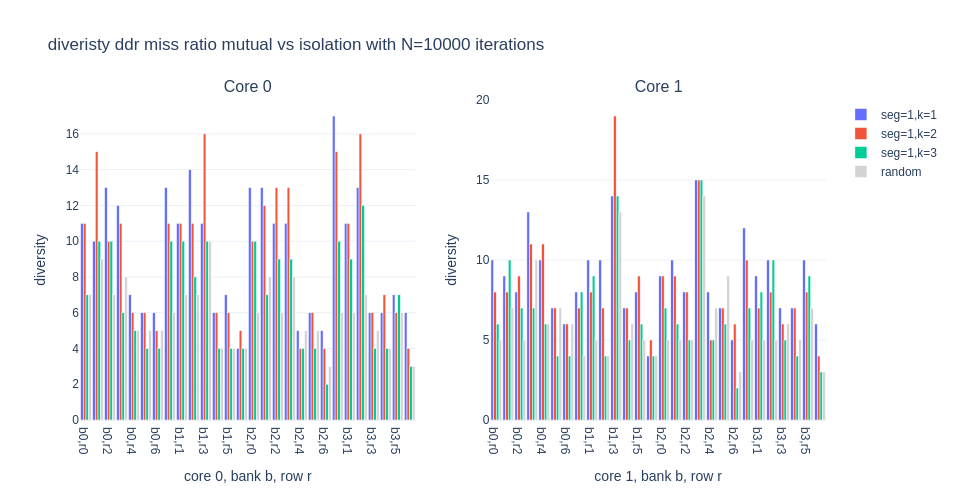

In [66]:

hist_diversity_misses(content_rand['memory_perf'],
        [load(f'{folder}/imgep_run_{k}_{N}_s_{s}')['memory_perf'] for k in [2,3,1] for s in s_list for folder in ['non_exclusive_axis_exploration']], 
        name=f"misses",
        num_row=7,
        title=f"diveristy ddr miss ratio mutual vs isolation with N={N} iterations",
        labels=[f'seg={s},k={k}' for k in range(1,4) for s in s_list]
    )

non_exclusive_axis_exploration/imgep_run_1_10000_s_1_0.pkl
non_exclusive_axis_exploration/imgep_run_2_10000_s_1_1.pkl
non_exclusive_axis_exploration/imgep_run_3_10000_s_1_1.pkl


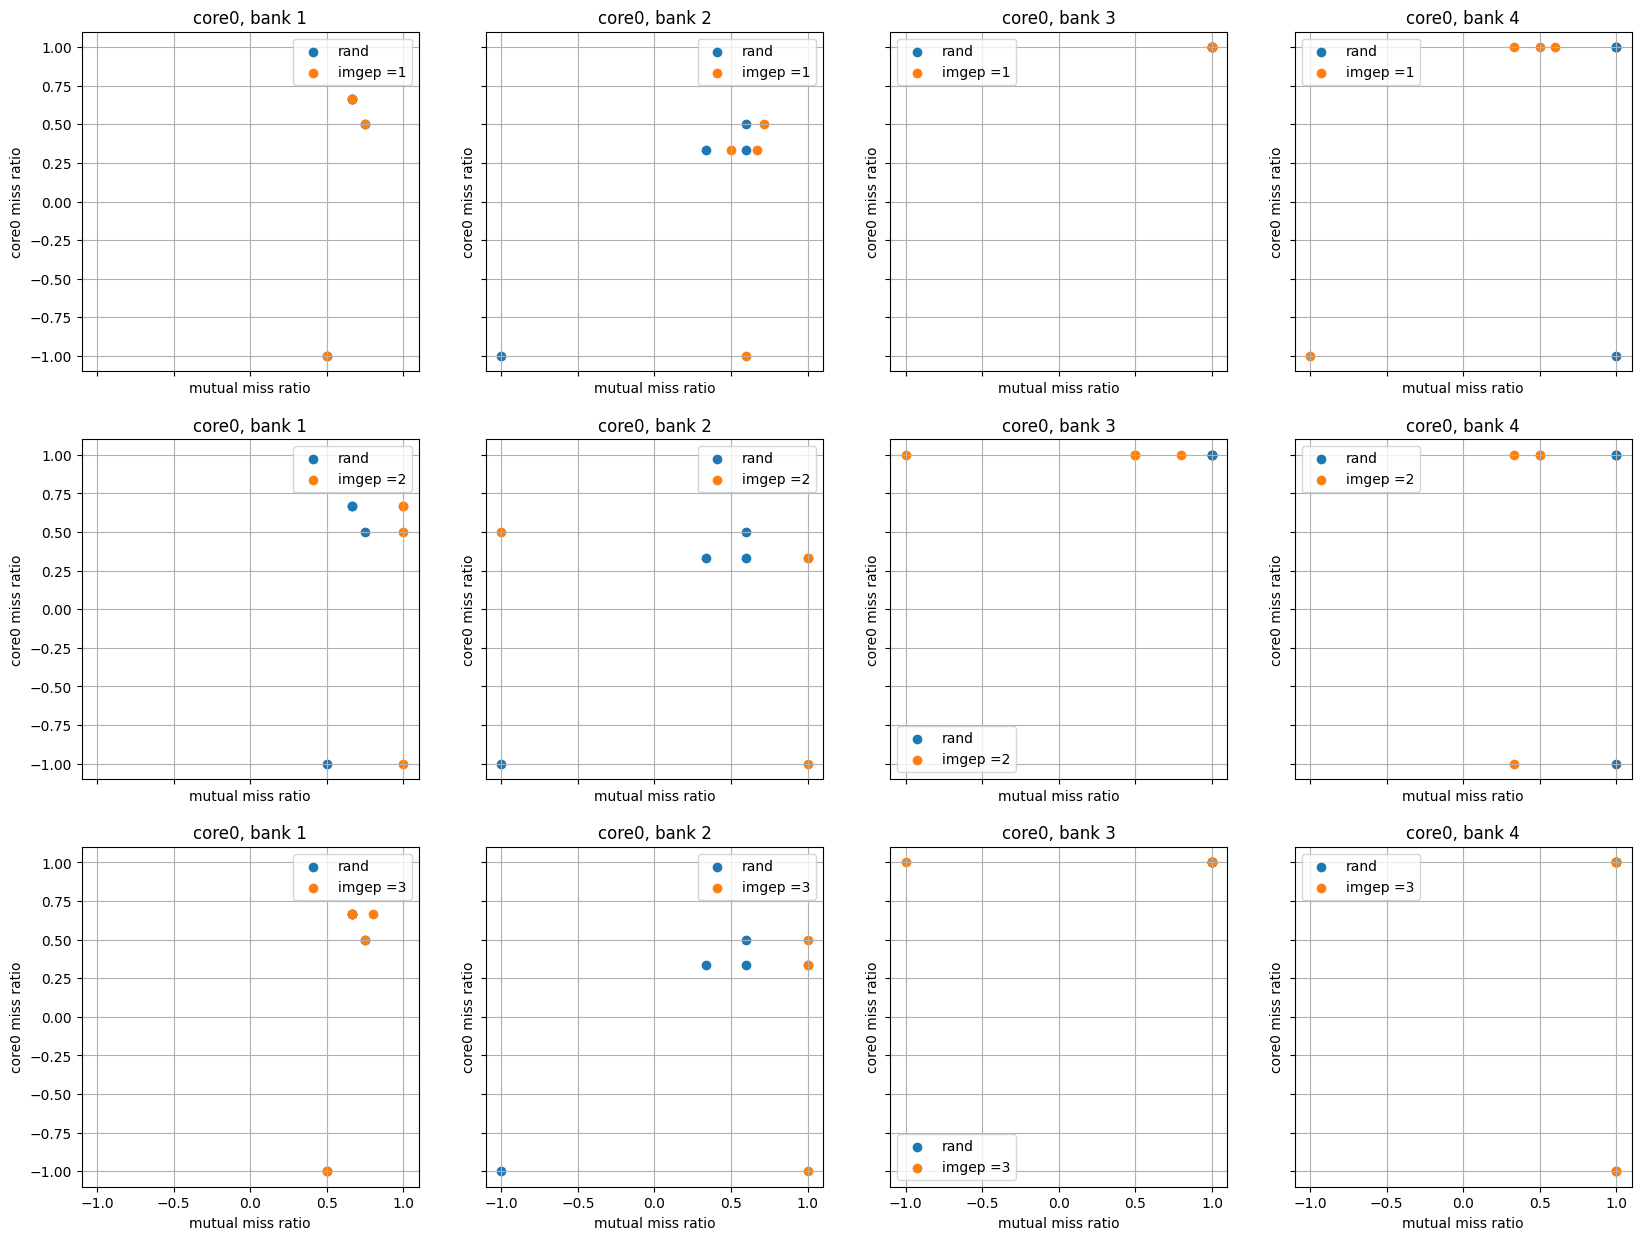

In [67]:

folder = 'non_exclusive_axis_exploration'
f, ax = plt.subplots(3, 4, sharey=True,sharex = True,figsize=(20,15))
for i,k in enumerate([1,2,3]):
    for s in s_list:
        name = f'{folder}/imgep_run_{k}_{N}_s_{s}'
        content_imgep = load(name)
        for j in range(4):
            ax[i,j].scatter(content_rand['memory_perf']['mutual']['miss_ratios_global'][j],content_rand['memory_perf']['core0']['miss_ratios_global'][j],label='rand')
            ax[i,j].scatter(content_imgep['memory_perf']['mutual']['miss_ratios_global'][j],content_rand['memory_perf']['core0']['miss_ratios_global'][j],label=f'imgep ={k}')
            ax[i,j].legend()
            ax[i,j].set_xlabel('mutual miss ratio')
            ax[i,j].set_ylabel('core0 miss ratio')
            ax[i,j].set_title(f'core0, bank {j+1}')
            ax[i,j].grid()
plt.show()